# Лабораторна робота 1 — Дослідження даних з NumPy, Pandas та scikit-learn

**Набір даних:** `kc_house_data.csv`  
**Дозволені бібліотеки:** NumPy, Pandas, Matplotlib, scikit-learn (усі модулі)

## Налаштування — встановлення залежностей та імпорт

Запустіть комірку нижче один раз, щоб переконатись, що всі необхідні пакети встановлені.

In [3]:
# Встановлення залежностей (можна запускати повторно)
import sys
!{sys.executable} -m pip install numpy pandas matplotlib scikit-learn --quiet



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)


---
## Завдання 1 — Розминка з NumPy

**а)** Створіть масив NumPy з 10 000 значень, що підпорядковані нормальному розподілу N(0, 1). Обчисліть середнє, стандартне відхилення, мінімум і максимум за допомогою функцій NumPy — **без Python-циклів**.

**б)** Підрахуйте, скільки значень виходять за межі ±2 стандартних відхилення, використовуючи логічну індексацію. Яка це відсоткова частка? Порівняйте з теоретичним значенням ≈4,55 %.

In [ ]:
# Завдання 1а — створіть масив і обчисліть статистику
np.random.seed(45)
data = np.random.randn(10000)

mean_val = np.mean(data)
std_val = np.std(data)
min_val = np.min(data)
max_val = np.max(data)

print(f"Середнє: {mean_val:.6f}")
print(f"Стандартне відхилення: {std_val:.6f}")
print(f"Мінімум: {min_val:.6f}")
print(f"Максимум: {max_val:.6f}")

Середнє: -0.002715
Стандартне відхилення: 0.995151
Мінімум: -3.424627
Максимум: 3.772364


In [39]:
# Завдання 1б — підрахуйте викиди за допомогою логічної індексації
lower_bound = mean_val - 2 * std_val
upper_bound = mean_val + 2 * std_val

outliers = data[(data < lower_bound) | (data > upper_bound)]

outliers_count = len(outliers)
outliers_percentage = (outliers_count / len(data)) * 100

print(f"Кількість значень за межами ±2 відхилень: {outliers_count}")
print(f"Відсоткова частка: {outliers_percentage:.2f}%")

Кількість значень за межами ±2 відхилень: 458
Відсоткова частка: 4.58%


**Ваша відповідь (б): Згідно з правилом двох сигм для нормального розподілу, близько 95.45% значень повинні знаходитися в межах $\mu \pm 2\sigma$. Відповідно, за цими межами має залишатися близько 4.55% викидів. Наша відсоткова частка 4.58% практично повністю збігається з теоретичним значенням, що підтверджує коректність згенерованої вибірки та правильність роботи нормального розподілу.

---
## Завдання 2 — Завантаження та огляд набору даних

Завантажте `kc_house_data.csv` у Pandas DataFrame та дайте відповідь на питання нижче, написавши код:

1. Скільки рядків і стовпців у наборі даних?
2. Які мінімум, максимум, середнє та медіана цін на будинки?
3. Скільки унікальних поштових індексів є у наборі даних? Який поштовий індекс має найбільше оголошень?

In [5]:
# Завантаження набору даних
sales = pd.read_csv('kc_house_data.csv')
sales.head()


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [6]:
# 2-і) Скільки рядків і стовпців?
num_rows, num_cols = sales.shape

print(f"Кількість рядків: {num_rows}")
print(f"Кількість стовпців: {num_cols}")

Кількість рядків: 21613
Кількість стовпців: 21


In [9]:
# 2-іі) Мінімум, максимум, середнє та медіана ціни
price_min = sales['price'].min()
price_max = sales['price'].max()
price_mean = sales['price'].mean()
price_median = sales['price'].median()

print(f"Мінімальна ціна: {price_min:.2f}")
print(f"Максимальна ціна: {price_max:.2f}")
print(f"Середня ціна: {price_mean:.2f}")
print(f"Медіанна ціна: {price_median:.2f}")

Мінімальна ціна: 75000.00
Максимальна ціна: 7700000.00
Середня ціна: 540088.14
Медіанна ціна: 450000.00


In [10]:
# 2-ііі) Кількість унікальних поштових індексів; індекс з найбільшою кількістю оголошень
unique_zipcodes = sales['zipcode'].nunique()
most_common_zipcode = sales['zipcode'].value_counts().idxmax()
most_common_count = sales['zipcode'].value_counts().max()

print(f"Унікальних поштових індексів: {unique_zipcodes}")
print(f"Індекс з найбільшою кількістю оголошень: {most_common_zipcode} ({most_common_count} оголошень)")

Унікальних поштових індексів: 70
Індекс з найбільшою кількістю оголошень: 98103 (602 оголошень)


---
## Завдання 3 — Візуалізація даних

Створіть **два графіки поруч**:

- **Лівий:** гістограма `price` (50 інтервалів, логарифмічна шкала по осі X).
- **Правий:** діаграма розсіювання `sqft_living` vs `price`, де кольором точок позначено `bedrooms`. Додайте підписи осей і colorbar.

Одним реченням для кожного графіка опишіть, що ви спостерігаєте.

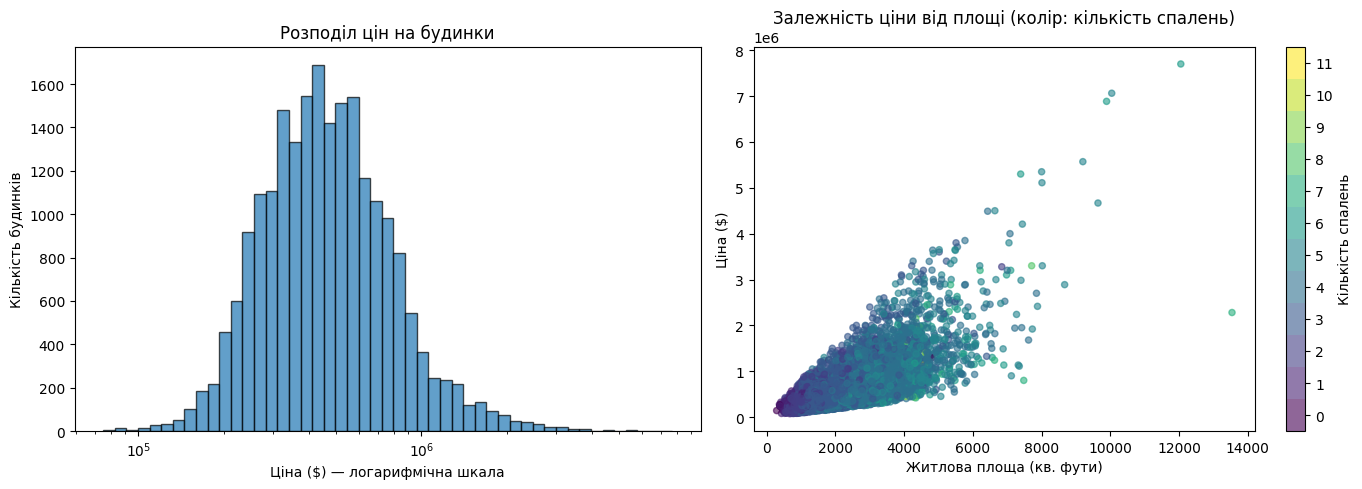

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Завдання 3 — лівий графік: гістограма ціни
log_bins = np.logspace(np.log10(sales['price'].min()), np.log10(sales['price'].max()), 50)
axes[0].hist(sales['price'], bins=log_bins, edgecolor='black', alpha=0.7)
axes[0].set_xscale('log')
axes[0].set_xlabel('Ціна ($) — логарифмічна шкала')
axes[0].set_ylabel('Кількість будинків')
axes[0].set_title('Розподіл цін на будинки')

# Завдання 3 — правий графік: діаграма розсіювання sqft_living vs price
cmap_discrete = plt.get_cmap('viridis', 12)
scatter = axes[1].scatter(sales['sqft_living'], sales['price'], 
                         c=sales['bedrooms'], cmap=cmap_discrete, 
                         alpha=0.6, s=20, vmin=-0.5, vmax=11.5) 

axes[1].set_xlabel('Житлова площа (кв. фути)')
axes[1].set_ylabel('Ціна ($)')
axes[1].set_title('Залежність ціни від площі (колір: кількість спалень)')
cbar = fig.colorbar(scatter, ax=axes[1], ticks=np.arange(0, 12))
cbar.set_label('Кількість спалень')

plt.tight_layout()
plt.show()


**Спостереження (лівий графік):** Завдяки переходу до логарифмічної шкали (як для значень осі X, так і для розбиття самих інтервалів), розподіл цін, який у лінійному вигляді мав сильну правосторонню асиметрію, візуально наблизився до нормального. Основна маса нерухомості зосереджена в середньому ціновому діапазоні (сотні тисяч доларів), проте зберігається довгий "хвіст" із рідкісних елітних об'єктів.

**Спостереження (правий графік):** Спостерігається чітка пряма залежність: зі збільшенням житлової площі закономірно зростає і ціна будинку. Дискретна колірна шкала наочно демонструє, що більші за площею будинки переважно мають більшу кількість спалень. Крім того, візуалізація дозволила ідентифікувати аномалію в даних - будинок із 33 спальнями, який при цьому має відносно невелику площу та лежить у середньому ціновому сегменті, що свідчить про ймовірну помилку під час введення даних.

---
## Завдання 4 — Навчання та оцінка регресійної моделі

Розбийте дані 80/20 (`random_state=42`). Навчіть `LinearRegression` з scikit-learn для передбачення `price` за єдиною ознакою `sqft_living`.

1. Вкажіть вільний член (intercept) та коефіцієнт для `sqft_living`.
2. Обчисліть MSE і RMSE на тестовій вибірці.
3. Яка передбачувана ціна будинку площею 2 500 кв. футів?

In [22]:
# Поділ на навчальну та тестову вибірки
train_data, test_data = train_test_split(sales, test_size=0.2, random_state=42)


1. Параметри моделі:
   Вільний член (Intercept): -41999.19
   Коефіцієнт для sqft_living: 279.55
   Рівняння: Ціна = 279.55 * Площа + (-41999.19)

2. Оцінка на тестовій вибірці:
   MSE: 76484977061.78
   RMSE: 276559.17 доларів

3. Прогноз:
   Очікувана ціна будинку площею 2500 кв. футів: 656887.76 доларів


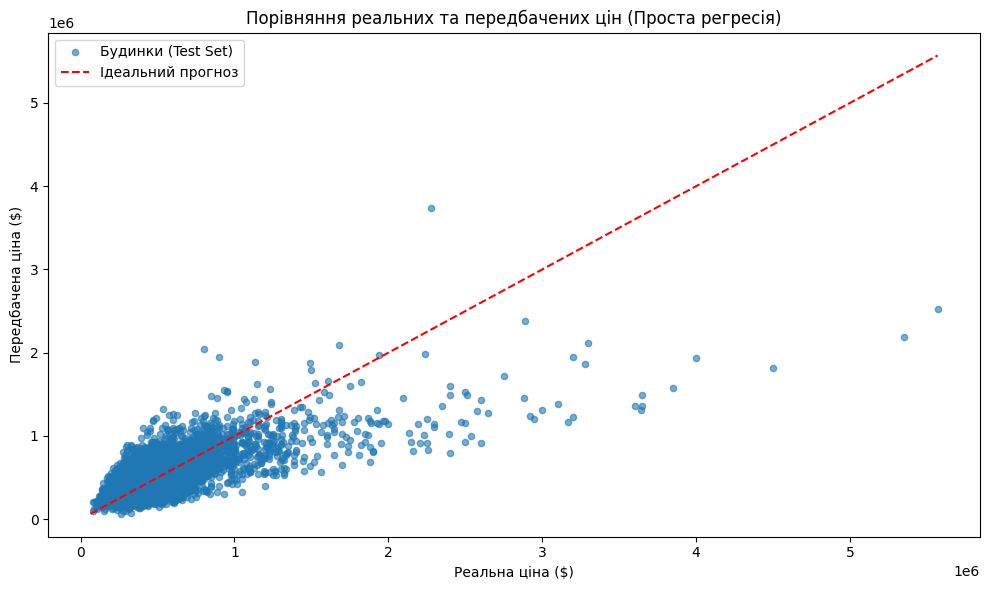

In [ ]:
# Завдання 4 — навчіть модель, вкажіть ваги, обчисліть MSE/RMSE, передбачте ціну для 2500 кв. фут.
X_train = train_data[['sqft_living']]
y_train = train_data['price']

X_test = test_data[['sqft_living']]
y_test = test_data['price']

model = LinearRegression()
model.fit(X_train, y_train)

intercept = model.intercept_
coef = model.coef_[0]

print(f"1. Параметри моделі:")
print(f"   Вільний член (Intercept): {intercept:.2f}")
print(f"   Коефіцієнт для sqft_living: {coef:.2f}")
print(f"   Рівняння: Ціна = {coef:.2f} * Площа + ({intercept:.2f})")

test_predictions = model.predict(X_test)
mse = mean_squared_error(y_test, test_predictions)
rmse = np.sqrt(mse)
print(f"\n2. Оцінка на тестовій вибірці:")
print(f"   MSE: {mse:.2f}")
print(f"   RMSE: {rmse:.2f} доларів")

house_2500 = pd.DataFrame({'sqft_living': [2500]})
predicted_price_2500 = model.predict(house_2500)[0]

print(f"\n3. Прогноз:")
print(f"   Очікувана ціна будинку площею 2500 кв. футів: {predicted_price_2500:.2f} доларів")


plt.figure(figsize=(10, 6))
plt.scatter(y_test, test_predictions, alpha=0.6, s=20, color='tab:blue', label='Будинки (Test Set)')

min_val = min(y_test.min(), test_predictions.min())
max_val = max(y_test.max(), test_predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Ідеальний прогноз')

plt.xlabel('Реальна ціна ($)')
plt.ylabel('Передбачена ціна ($)')
plt.title('Порівняння реальних та передбачених цін (Проста регресія)')
plt.legend()
plt.tight_layout()
plt.show()

---
## Завдання 5 — Порівняння двох моделей

Навчіть другу `LinearRegression` з ознаками: `sqft_living`, `bedrooms`, `bathrooms`, `yr_built`. Порівняйте RMSE на тестовій вибірці між Моделлю 1 та Моделлю 2. Яке значення нижче? Коротко поясніть чому.

In [ ]:
# Завдання 5 — модель з чотирма ознаками та порівняння RMSE
features = ['sqft_living', 'bedrooms', 'bathrooms', 'yr_built']

X_train_multi = train_data[features]
X_test_multi = test_data[features]

y_train = train_data['price']
y_test = test_data['price']

model_multi = LinearRegression()
model_multi.fit(X_train_multi, y_train)

predictions_multi = model_multi.predict(X_test_multi)
mse_multi = mean_squared_error(y_test, predictions_multi)
rmse_multi = np.sqrt(mse_multi)

print("--- ПОРІВНЯННЯ МОДЕЛЕЙ ---")
print(f"RMSE Моделі 1 (Тільки sqft_living): {rmse:.2f} доларів")
print(f"RMSE Моделі 2 (4 ознаки):         {rmse_multi:.2f} доларів")

difference = rmse - rmse_multi
print(f"\nРізниця: Модель 2 помиляється в середньому на {difference:.2f} доларів менше.")

print("\n--- ВАГИ МОДЕЛІ ---")
for feature, weight in zip(features, model_multi.coef_):
    print(f"{feature}: {weight:.2f}")


--- ПОРІВНЯННЯ МОДЕЛЕЙ ---
RMSE Моделі 1 (Тільки sqft_living): 276559.17 доларів
RMSE Моделі 2 (4 ознаки):         262985.98 доларів

Різниця: Модель 2 помиляється в середньому на 13573.20 доларів менше.

--- ВАГИ МОДЕЛЕЙ (Коефіцієнти) ---
sqft_living: 296.13
bedrooms: -68991.68
bathrooms: 88164.06
yr_built: -3116.42


**Відповідь:** RMSE другої моделі (262,985.98) виявився нижчим за показник першої (276,559.17), що свідчить про підвищення точності прогнозу. Це пояснюється тим, що додавання ознак bedrooms, bathrooms та yr_built дозволило алгоритму врахувати додаткові фактори впливу на ціну, зменшивши ефект недонавчання. Однак помилка все ще залишається високою, а від'ємний коефіцієнт для спалень (-68,991.68) вказує на те, що при незмінній площі збільшення кількості кімнат знижує вартість через зменшення вільного простору. Для радикального покращення моделі необхідно враховувати також інші ознаки (наприклад, географічне розташування об'єктів).

---
## ✨ Бонус — Аналіз залишків

Для вашої кращої моделі обчисліть вектор залишків (predicted − actual). Побудуйте гістограму. Чи виглядають залишки нормально розподіленими та центрованими навколо нуля? Що означав би систематичний ненульовий середній залишок?

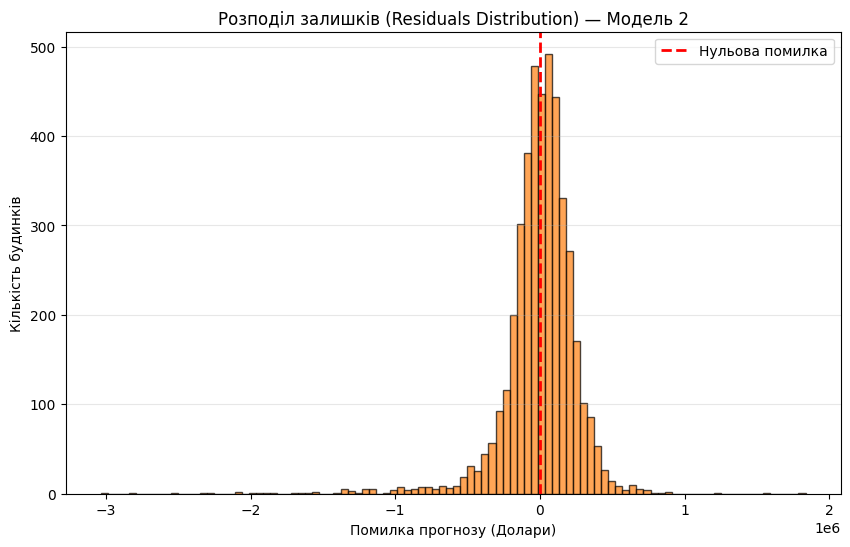

Середній залишок: -1611.51


In [35]:
# Бонус — аналіз залишків
residuals = predictions_multi - y_test

plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=100, edgecolor='black', alpha=0.7, color='tab:orange')
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Нульова помилка')

plt.xlabel('Помилка прогнозу (Долари)')
plt.ylabel('Кількість будинків')
plt.title('Розподіл залишків (Residuals Distribution) — Модель 2')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

mean_residual = np.mean(residuals)
print(f"Середній залишок: {mean_residual:.2f}")

**Спостереження:** Розподіл залишків має виражений пік у районі нуля, що свідчить про те, що для значної частини об'єктів модель робить прогнози з мінімальною похибкою. Проте форма розподілу не є ідеально симетричною («дзвоноподібною»): ми спостерігаємо довгий «правий хвіст». Це вказує на наявність суттєвих позитивних помилок, коли модель значно переоцінює вартість окремих будинків, видаючи прогноз, що набагато перевищує реальну ціну продажу.

Середнє значення залишків наближається до нуля, що підтверджує відсутність критичного систематичного зміщення — модель не занижує і не завищує ціни глобально по всьому ринку. Однак значна ширина розкиду підтверджує раніше отриманий показник RMSE: модель все ще допускає великі помилки в окремих випадках через брак даних.

Систематичний ненульовий середній залишок свідчив би про фундаментальну проблему в моделі, наприклад, якщо б вона постійно «оптимістично» оцінювала нерухомість вище ринку. У нашому випадку залишки розподілені відносно центровано, але висока дисперсія (ширина графіка) наочно демонструє, що лінійна залежність від чотирьох обраних ознак не здатна повністю пояснити ціноутворення в цьому датасеті.